In [ ]:
import numpy as np
import  pandas as pd

In [ ]:
courses=pd.read_csv("courses.csv")
deli=pd.read_csv("deliveries.csv")
mat=pd.read_csv("matches.csv")
nov=pd.read_csv("reg-month1.csv")
dec=pd.read_csv("reg-month2.csv")
stud=pd.read_csv("students.csv")

In [ ]:
hhh=pd.concat([nov,dec]).reset_index()
hhh

In [19]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [71]:
regs=pd.concat([nov,dec],keys=["november","december"]).reset_index()
regs

,level_0,level_1,student_id,course_id
0,november,0,23,1
1,november,1,15,5
2,november,2,18,6
3,november,3,23,4
4,november,4,16,9
5,november,5,18,1
6,november,6,1,1
7,november,7,7,8
8,november,8,22,3
9,november,9,15,1


In [ ]:
hhh

In [ ]:
pd.concat([nov,dec],axis=1)

In [ ]:
#inner join

stud.merge(nov,how="inner",on="student_id")

In [ ]:
#lef join

courses.merge(nov,how="left",on="course_id")

In [25]:
#total revennue generated


purchse=pd.concat([nov,dec],ignore_index=True)
purchse

total_revenue=courses.merge(purchse,how="inner",on="course_id")["price"].sum()
total_revenue


np.int64(154247)

In [56]:
#find month by month revenue
temp_month=pd.concat([nov,dec],keys=["november","december"]).reset_index()
temp_month

temp_month.merge(courses,on="course_id").groupby("level_0")["price"].sum()


level_0
december    65072
november    89175
Name: price, dtype: int64

In [79]:
#regiration table 
#col->name->courses->prices



In [83]:
regs.merge(stud,on="student_id").merge(courses,on="course_id")[["name","course_name","price"]]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

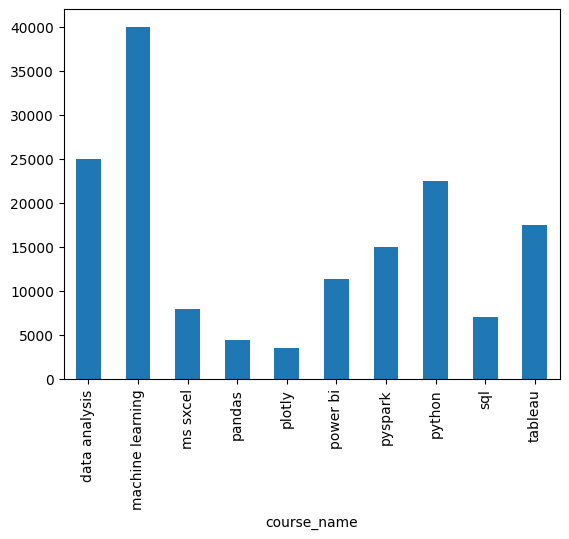

In [90]:
#plots a bar revena  and courses

graph=regs.merge(courses,on="course_id").groupby("course_name")["price"].sum()
graph.plot(kind="bar")

In [95]:
#who enlooed in both month
#ye series aaya es liye np ka saab use hoga

common_student=np.intersect1d(nov["student_id"],dec["student_id"])
common_student


array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [101]:
stud[stud["student_id"].isin(common_student)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [117]:
#fin courses which have no enloment

no_enrollment=np.setdiff1d(courses["course_id"],regs["course_id"])
no_enrollment
courses[courses["course_id"].isin(no_enrollment)]


,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [126]:
#find thre student who dooes not enlooment in any courses
no_student=np.setdiff1d(stud["student_id"],regs["student_id"])
no_student


stud[stud["student_id"].isin(no_student)]


,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11


In [136]:
#name studet namr  partner name who enroolment in course
#self join


stud.merge(stud,left_on="partner",right_on="student_id")[["name_x","name_y"]]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [163]:
#top 3 student student who enrollment mor

regs.merge(stud,on="student_id").groupby(["student_id","name"])["name"].count().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64

In [173]:
#top 3 student who spent more on cousers enrollment
regs.merge(stud,on="student_id").merge(courses,on="course_id").groupby(["student_id","name" ])["price"].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64